# Image Tampering Detection - ELA + Dual-Stream ResNet50

## Approach
Error Level Analysis (ELA) highlights JPEG compression inconsistencies in tampered images.
When a JPEG is re-saved, tampered regions compress differently from authentic ones.

**Pipeline:**
1. Load preprocessed CASIA v2.0 images
2. Compute ELA maps for each image
3. Train three models: RGB-only, ELA-only, Dual-Stream (RGB + ELA)
4. All models use ImageNet normalization, cosine LR schedule, and early stopping

In [1]:
import sys, io
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from torchvision import models
import torchvision.transforms.functional as TF
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, classification_report, confusion_matrix,
                              ConfusionMatrixDisplay)
from PIL import Image
from pathlib import Path
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

torch.backends.cudnn.benchmark = True
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'CUDA: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')
print(f'Device: {device}')

CUDA: True
GPU: NVIDIA GeForce RTX 5070 Ti
Device: cuda


## 1. Load Data

In [2]:
DATA_DIR = Path('.')

train_data = np.load(DATA_DIR / 'casia_train.npz')
val_data   = np.load(DATA_DIR / 'casia_val.npz')
test_data  = np.load(DATA_DIR / 'casia_test.npz')

X_train, y_train = train_data['images'].astype(np.float32), train_data['labels']
X_val,   y_val   = val_data['images'].astype(np.float32),   val_data['labels']
X_test,  y_test  = test_data['images'].astype(np.float32),  test_data['labels']

print(f'Train: {X_train.shape}  Val: {X_val.shape}  Test: {X_test.shape}')
print(f'Raw value range: [{X_train.min():.3f}, {X_train.max():.3f}]')

# Data is already ImageNet-normalized in the .npz files!
# Denormalize back to [0,1] pixel space so ELA and normalization work correctly.
IMAGENET_MEAN_NP = np.array([0.485, 0.456, 0.406], dtype=np.float32)
IMAGENET_STD_NP  = np.array([0.229, 0.224, 0.225], dtype=np.float32)

for arr in [X_train, X_val, X_test]:
    arr[:] = arr * IMAGENET_STD_NP + IMAGENET_MEAN_NP
    arr[:] = arr.clip(0.0, 1.0)

print(f'After denorm:    [{X_train.min():.3f}, {X_train.max():.3f}]')
for name, y in [('Train', y_train), ('Val', y_val), ('Test', y_test)]:
    print(f'  {name}: Authentic={np.sum(y==0)}, Tampered={np.sum(y==1)}')

Train: (10091, 224, 224, 3)  Val: (1261, 224, 224, 3)  Test: (1262, 224, 224, 3)
Raw value range: [-2.118, 2.640]
After denorm:    [0.000, 1.000]
  Train: Authentic=5993, Tampered=4098
  Val: Authentic=749, Tampered=512
  Test: Authentic=749, Tampered=513


## 2. Error Level Analysis (ELA)

ELA detects image tampering by re-saving the image as JPEG at a known quality level and measuring the pixel-level difference.

- **Authentic images** have uniform compression artifacts -> uniform ELA response
- **Tampered images** have inconsistent compression in spliced regions -> brighter ELA in tampered areas

In [3]:
def compute_ela(images, quality=90, scale=15.0):
    """Compute Error Level Analysis maps.
    images: (N, 224, 224, 3) float32 in [0,1]
    Returns: (N, 224, 224, 3) float32 in [0,1]
    """
    n = len(images)
    ela = np.empty_like(images)
    for i in tqdm(range(n), desc='ELA', ncols=80):
        img_u8 = (images[i].clip(0, 1) * 255).astype(np.uint8)
        pil = Image.fromarray(img_u8)
        buf = io.BytesIO()
        pil.save(buf, format='JPEG', quality=quality)
        buf.seek(0)
        resaved = np.array(Image.open(buf), dtype=np.float32)
        diff = np.abs(img_u8.astype(np.float32) - resaved)
        ela[i] = (diff * scale / 255.0).clip(0.0, 1.0)
    return ela

print('Computing ELA maps...')
ELA_train = compute_ela(X_train)
ELA_val   = compute_ela(X_val)
ELA_test  = compute_ela(X_test)
print(f'Done. ELA shape: {ELA_train.shape}')

Computing ELA maps...


ELA: 100%|████████████████████████████████| 1262/1262 [00:00<00:00, 1447.70it/s]

Done. ELA shape: (10091, 224, 224, 3)


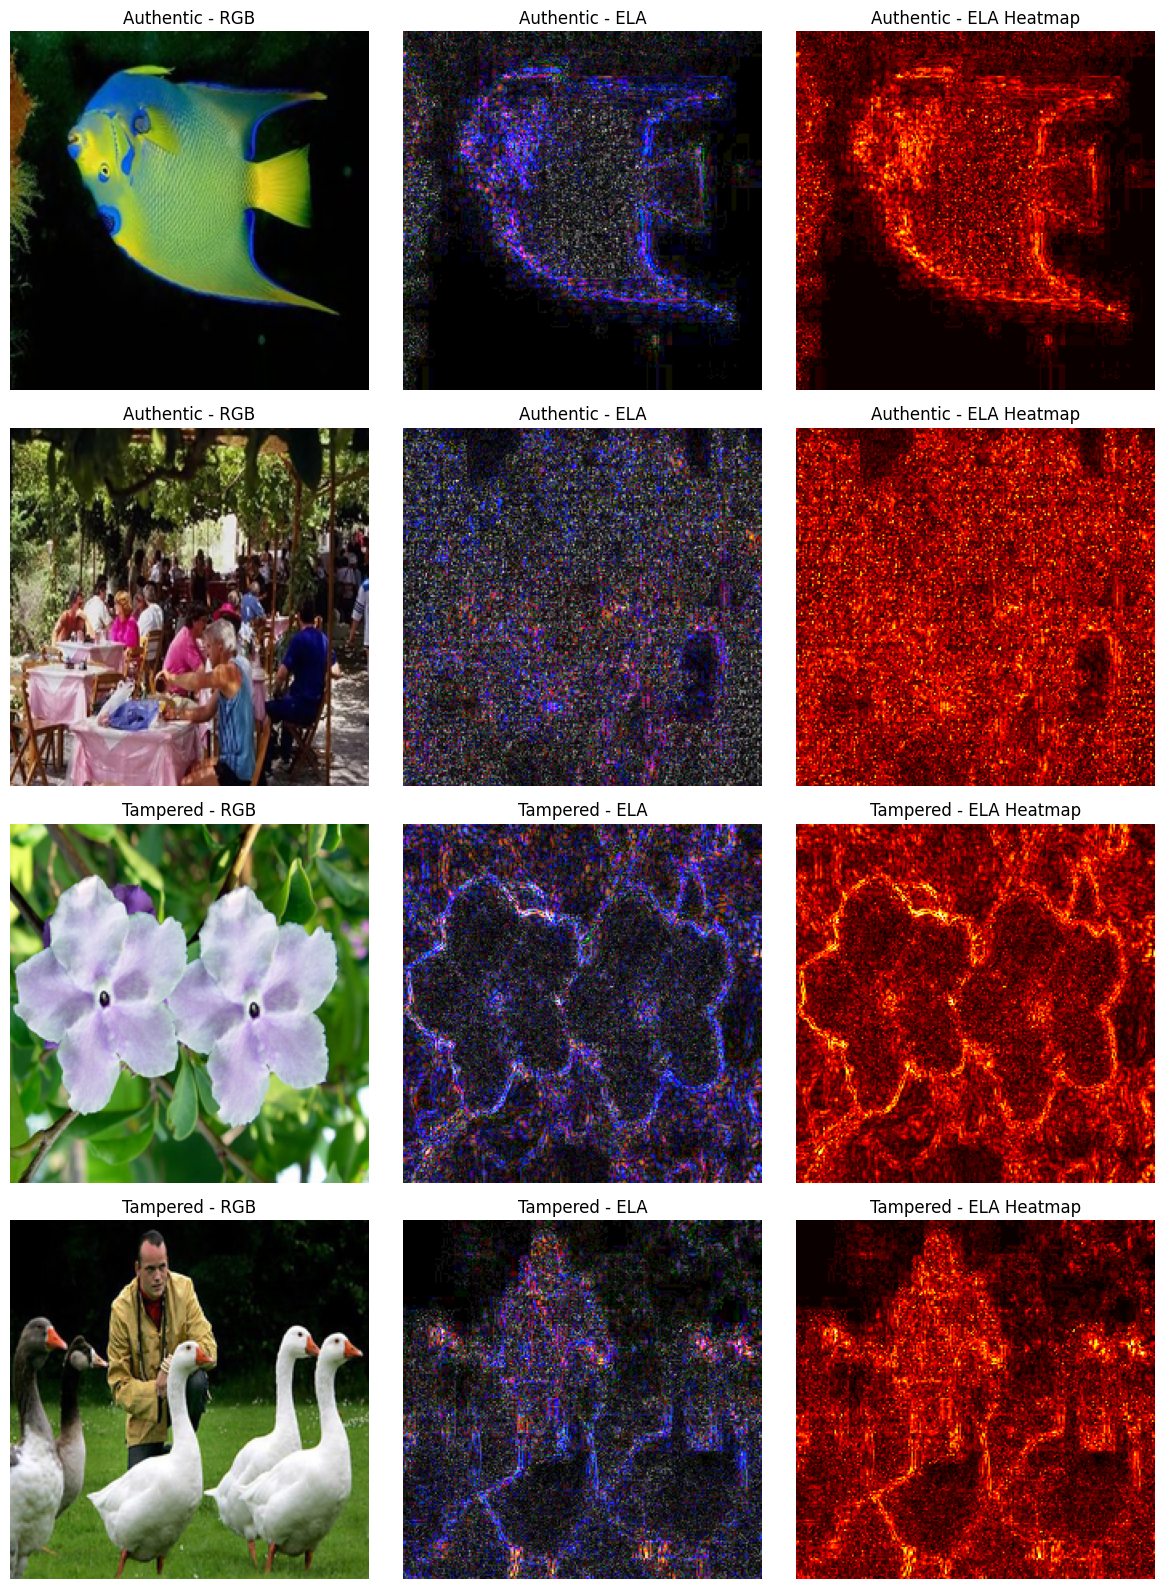

In [4]:
fig, axes = plt.subplots(4, 3, figsize=(12, 16))
au_idx = np.where(y_train == 0)[0][:2]
tp_idx = np.where(y_train == 1)[0][:2]

for row, idx in enumerate(list(au_idx) + list(tp_idx)):
    tag = 'Authentic' if y_train[idx] == 0 else 'Tampered'
    axes[row, 0].imshow(X_train[idx].clip(0, 1))
    axes[row, 0].set_title(f'{tag} - RGB')
    axes[row, 0].axis('off')
    axes[row, 1].imshow(ELA_train[idx].clip(0, 1))
    axes[row, 1].set_title(f'{tag} - ELA')
    axes[row, 1].axis('off')
    axes[row, 2].imshow(ELA_train[idx].mean(axis=2), cmap='hot')
    axes[row, 2].set_title(f'{tag} - ELA Heatmap')
    axes[row, 2].axis('off')

plt.tight_layout()
plt.show()

## 3. Dataset & Training Setup

In [5]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]


class SingleStreamDataset(Dataset):
    """Dataset for single-input models (RGB or ELA)."""
    def __init__(self, images, labels, augment=False):
        self.images = images
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        img = torch.from_numpy(self.images[idx]).permute(2, 0, 1)
        lbl = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.augment and torch.rand(1).item() > 0.5:
            img = TF.hflip(img)
        img = TF.normalize(img, IMAGENET_MEAN, IMAGENET_STD)
        return img, lbl


class DualStreamDataset(Dataset):
    """Dataset for dual-input models (RGB + ELA)."""
    def __init__(self, rgb, ela, labels, augment=False):
        self.rgb = rgb
        self.ela = ela
        self.labels = labels
        self.augment = augment

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        rgb = torch.from_numpy(self.rgb[idx]).permute(2, 0, 1)
        ela = torch.from_numpy(self.ela[idx]).permute(2, 0, 1)
        lbl = torch.tensor(self.labels[idx], dtype=torch.float32)
        if self.augment and torch.rand(1).item() > 0.5:
            rgb = TF.hflip(rgb)
            ela = TF.hflip(ela)
        rgb = TF.normalize(rgb, IMAGENET_MEAN, IMAGENET_STD)
        ela = TF.normalize(ela, IMAGENET_MEAN, IMAGENET_STD)
        return rgb, ela, lbl


def evaluate_model(model, loader, dual=False):
    """Get predictions from a model."""
    model.eval()
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in loader:
            if dual:
                rgb, ela, y = batch
                logits = model(rgb.to(device), ela.to(device)).squeeze(1)
            else:
                x, y = batch
                logits = model(x.to(device)).squeeze(1)
            preds = (torch.sigmoid(logits) >= 0.5).cpu().numpy()
            all_preds.append(preds)
            all_labels.append(y.numpy())
    return np.concatenate(all_preds), np.concatenate(all_labels)


def train_model(model, train_loader, val_loader, num_epochs=20, patience=5,
                lr_backbone=1e-5, lr_head=1e-3, dual=False):
    """Train with early stopping and cosine LR schedule."""
    if dual:
        backbone_params = []
        for bb in [model.rgb_backbone, model.ela_backbone]:
            backbone_params += [p for p in bb.parameters() if p.requires_grad]
        head_params = list(model.classifier.parameters())
    else:
        backbone_params = [p for n, p in model.named_parameters()
                          if p.requires_grad and 'fc' not in n]
        head_params = list(model.fc.parameters())

    optimizer = torch.optim.AdamW([
        {'params': backbone_params, 'lr': lr_backbone},
        {'params': head_params,     'lr': lr_head},
    ], weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)
    criterion = nn.BCEWithLogitsLoss()

    best_f1, best_state, wait = 0.0, None, 0
    history = {'loss': [], 'val_acc': [], 'val_f1': []}

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        for batch in train_loader:
            if dual:
                rgb, ela, y = [t.to(device) for t in batch]
                logits = model(rgb, ela).squeeze(1)
            else:
                x, y = batch[0].to(device), batch[1].to(device)
                logits = model(x).squeeze(1)
            loss = criterion(logits, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss += loss.item() * y.size(0)

        scheduler.step()
        avg_loss = total_loss / len(train_loader.dataset)
        preds, labels = evaluate_model(model, val_loader, dual)
        vacc = accuracy_score(labels, preds)
        vf1  = f1_score(labels, preds)
        history['loss'].append(avg_loss)
        history['val_acc'].append(vacc)
        history['val_f1'].append(vf1)

        star = ' *' if vf1 > best_f1 else ''
        print(f'  Epoch {epoch+1:2d}/{num_epochs}  loss={avg_loss:.4f}  val_acc={vacc:.4f}  val_f1={vf1:.4f}{star}')

        if vf1 > best_f1:
            best_f1 = vf1
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            wait = 0
        else:
            wait += 1
            if wait >= patience:
                print(f'  Early stopping at epoch {epoch+1}')
                break

    model.load_state_dict(best_state)
    model.to(device)
    print(f'  Best val F1: {best_f1:.4f}')
    return history

print('Setup complete.')

Setup complete.


## 4. Model A - RGB ResNet50 (Improved Baseline)

Key improvements over previous notebook:
- **ImageNet normalization** applied (was missing before)
- **Layer3 + Layer4** unfrozen (previously only Layer4)
- **AdamW** with cosine LR schedule + early stopping

In [6]:
rgb_train_loader = DataLoader(
    SingleStreamDataset(X_train, y_train, augment=True),
    batch_size=32, shuffle=True, num_workers=0)
rgb_val_loader = DataLoader(
    SingleStreamDataset(X_val, y_val),
    batch_size=64, num_workers=0)
rgb_test_loader = DataLoader(
    SingleStreamDataset(X_test, y_test),
    batch_size=64, num_workers=0)

model_a = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for p in model_a.parameters():
    p.requires_grad = False
for p in model_a.layer3.parameters():
    p.requires_grad = True
for p in model_a.layer4.parameters():
    p.requires_grad = True
model_a.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(2048, 1))
model_a = model_a.to(device)

n_params = sum(p.numel() for p in model_a.parameters() if p.requires_grad)
print(f'Model A (RGB): {n_params:,} trainable params')
print('Training...')
hist_a = train_model(model_a, rgb_train_loader, rgb_val_loader)

Model A (RGB): 22,065,153 trainable params
Training...
  Epoch  1/20  loss=0.5960  val_acc=0.7058  val_f1=0.6147 *
  Epoch  2/20  loss=0.4973  val_acc=0.7415  val_f1=0.7020 *
  Epoch  3/20  loss=0.4217  val_acc=0.7351  val_f1=0.7039 *
  Epoch  4/20  loss=0.3621  val_acc=0.7367  val_f1=0.6844
  Epoch  5/20  loss=0.3275  val_acc=0.7304  val_f1=0.6660
  Epoch  6/20  loss=0.2894  val_acc=0.7312  val_f1=0.6835
  Epoch  7/20  loss=0.2564  val_acc=0.7304  val_f1=0.6737
  Epoch  8/20  loss=0.2353  val_acc=0.7145  val_f1=0.6407
  Early stopping at epoch 8
  Best val F1: 0.7039


## 5. Model B - ELA-only ResNet50

Same architecture, but trained on ELA images instead of RGB.
Tests whether ELA alone captures more tampering signal than raw pixels.

In [7]:
ela_train_loader = DataLoader(
    SingleStreamDataset(ELA_train, y_train, augment=True),
    batch_size=32, shuffle=True, num_workers=0)
ela_val_loader = DataLoader(
    SingleStreamDataset(ELA_val, y_val),
    batch_size=64, num_workers=0)
ela_test_loader = DataLoader(
    SingleStreamDataset(ELA_test, y_test),
    batch_size=64, num_workers=0)

model_b = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
for p in model_b.parameters():
    p.requires_grad = False
for p in model_b.layer3.parameters():
    p.requires_grad = True
for p in model_b.layer4.parameters():
    p.requires_grad = True
model_b.fc = nn.Sequential(nn.Dropout(0.4), nn.Linear(2048, 1))
model_b = model_b.to(device)

n_params = sum(p.numel() for p in model_b.parameters() if p.requires_grad)
print(f'Model B (ELA): {n_params:,} trainable params')
print('Training...')
hist_b = train_model(model_b, ela_train_loader, ela_val_loader)

Model B (ELA): 22,065,153 trainable params
Training...
  Epoch  1/20  loss=0.6003  val_acc=0.7224  val_f1=0.5882 *
  Epoch  2/20  loss=0.4953  val_acc=0.7526  val_f1=0.6688 *
  Epoch  3/20  loss=0.4120  val_acc=0.7470  val_f1=0.6588
  Epoch  4/20  loss=0.3053  val_acc=0.7510  val_f1=0.6572
  Epoch  5/20  loss=0.2055  val_acc=0.7462  val_f1=0.6646
  Epoch  6/20  loss=0.1539  val_acc=0.7391  val_f1=0.6803 *
  Epoch  7/20  loss=0.1060  val_acc=0.7399  val_f1=0.6765
  Epoch  8/20  loss=0.0799  val_acc=0.7209  val_f1=0.6673
  Epoch  9/20  loss=0.0567  val_acc=0.7454  val_f1=0.6787
  Epoch 10/20  loss=0.0447  val_acc=0.7478  val_f1=0.6536
  Epoch 11/20  loss=0.0354  val_acc=0.7454  val_f1=0.6596
  Early stopping at epoch 11
  Best val F1: 0.6803


## 6. Model C - Dual-Stream (RGB + ELA)

Two ResNet50 backbones process RGB and ELA images separately.
Features are concatenated (2048 + 2048 = 4096) and passed through a fusion classifier.

In [8]:
class DualStreamResNet(nn.Module):
    def __init__(self):
        super().__init__()
        rgb_net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.rgb_backbone = nn.Sequential(*list(rgb_net.children())[:-1])
        ela_net = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
        self.ela_backbone = nn.Sequential(*list(ela_net.children())[:-1])

        for backbone in [self.rgb_backbone, self.ela_backbone]:
            for p in backbone.parameters():
                p.requires_grad = False
            for idx in [6, 7]:  # layer3, layer4
                for p in backbone[idx].parameters():
                    p.requires_grad = True

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(4096, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 1)
        )

    def forward(self, rgb, ela):
        r = self.rgb_backbone(rgb).flatten(1)
        e = self.ela_backbone(ela).flatten(1)
        return self.classifier(torch.cat([r, e], dim=1))


dual_train_loader = DataLoader(
    DualStreamDataset(X_train, ELA_train, y_train, augment=True),
    batch_size=32, shuffle=True, num_workers=0)
dual_val_loader = DataLoader(
    DualStreamDataset(X_val, ELA_val, y_val),
    batch_size=32, num_workers=0)
dual_test_loader = DataLoader(
    DualStreamDataset(X_test, ELA_test, y_test),
    batch_size=32, num_workers=0)

model_c = DualStreamResNet().to(device)
n_params = sum(p.numel() for p in model_c.parameters() if p.requires_grad)
print(f'Model C (Dual-Stream): {n_params:,} trainable params')
print('Training...')
hist_c = train_model(model_c, dual_train_loader, dual_val_loader, dual=True)

Model C (Dual-Stream): 45,175,297 trainable params
Training...
  Epoch  1/20  loss=0.5731  val_acc=0.7621  val_f1=0.7222 *
  Epoch  2/20  loss=0.4471  val_acc=0.7780  val_f1=0.7358 *
  Epoch  3/20  loss=0.3490  val_acc=0.7676  val_f1=0.7043
  Epoch  4/20  loss=0.2853  val_acc=0.7708  val_f1=0.7351
  Epoch  5/20  loss=0.2172  val_acc=0.7518  val_f1=0.6777
  Epoch  6/20  loss=0.1617  val_acc=0.7542  val_f1=0.6943
  Epoch  7/20  loss=0.1234  val_acc=0.7708  val_f1=0.7213
  Early stopping at epoch 7
  Best val F1: 0.7358


## 7. Test Evaluation & Comparison

In [9]:
results = {}

for name, model, loader, dual in [
    ('A: RGB (improved)', model_a, rgb_test_loader, False),
    ('B: ELA-only', model_b, ela_test_loader, False),
    ('C: Dual-Stream', model_c, dual_test_loader, True),
]:
    preds, labels = evaluate_model(model, loader, dual)
    results[name] = {
        'preds': preds, 'labels': labels,
        'Accuracy': accuracy_score(labels, preds),
        'Precision': precision_score(labels, preds),
        'Recall': recall_score(labels, preds),
        'F1 Score': f1_score(labels, preds),
    }
    print(f'\n{"="*50}')
    print(name)
    print(f'{"="*50}')
    print(classification_report(labels, preds, target_names=['Authentic', 'Tampered']))

# Previous baseline reference
results['Prev. Baseline'] = {
    'Accuracy': 0.6767, 'Precision': 0.5926, 'Recall': 0.6550, 'F1 Score': 0.6222,
    'preds': None, 'labels': None,
}


A: RGB (improved)
              precision    recall  f1-score   support

   Authentic       0.83      0.70      0.76       749
    Tampered       0.64      0.79      0.71       513

    accuracy                           0.74      1262
   macro avg       0.74      0.74      0.73      1262
weighted avg       0.75      0.74      0.74      1262


B: ELA-only
              precision    recall  f1-score   support

   Authentic       0.79      0.77      0.78       749
    Tampered       0.67      0.70      0.69       513

    accuracy                           0.74      1262
   macro avg       0.73      0.73      0.73      1262
weighted avg       0.74      0.74      0.74      1262


C: Dual-Stream
              precision    recall  f1-score   support

   Authentic       0.80      0.77      0.79       749
    Tampered       0.69      0.72      0.70       513

    accuracy                           0.75      1262
   macro avg       0.74      0.75      0.75      1262
weighted avg       0.76   

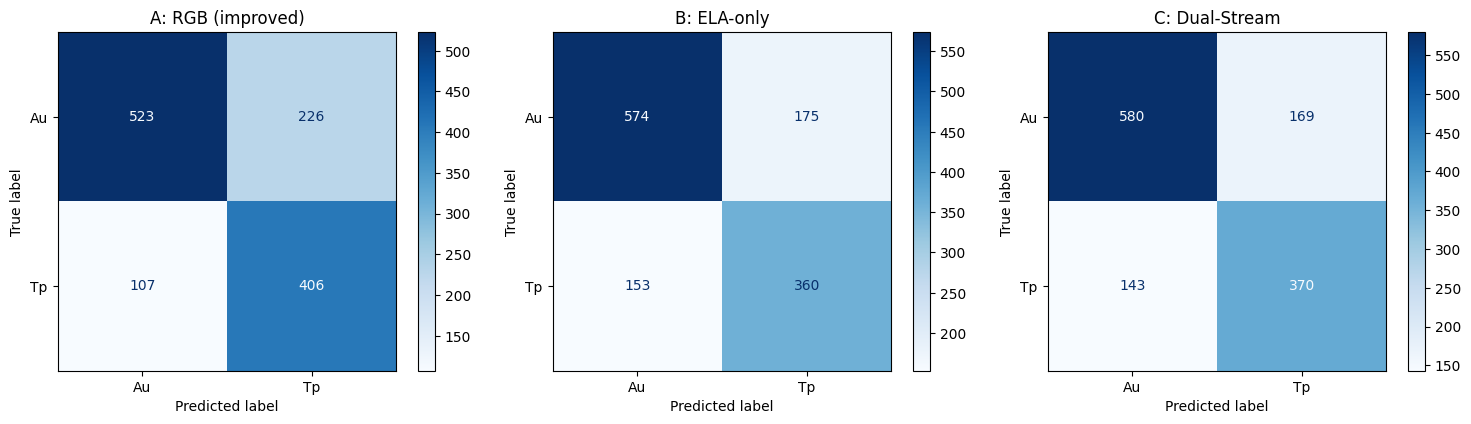

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
plot_names = [n for n in results if results[n]['preds'] is not None]

for ax, name in zip(axes, plot_names):
    r = results[name]
    cm = confusion_matrix(r['labels'], r['preds'])
    ConfusionMatrixDisplay(cm, display_labels=['Au', 'Tp']).plot(ax=ax, cmap=plt.cm.Blues)
    ax.set_title(name)

plt.tight_layout()
plt.show()

Test Set Comparison:
           Prev. Baseline  A: RGB (improved)  B: ELA-only  C: Dual-Stream
Accuracy           0.6767             0.7361       0.7401          0.7528
Precision          0.5926             0.6424       0.6729          0.6865
Recall             0.6550             0.7914       0.7018          0.7212
F1 Score           0.6222             0.7092       0.6870          0.7034


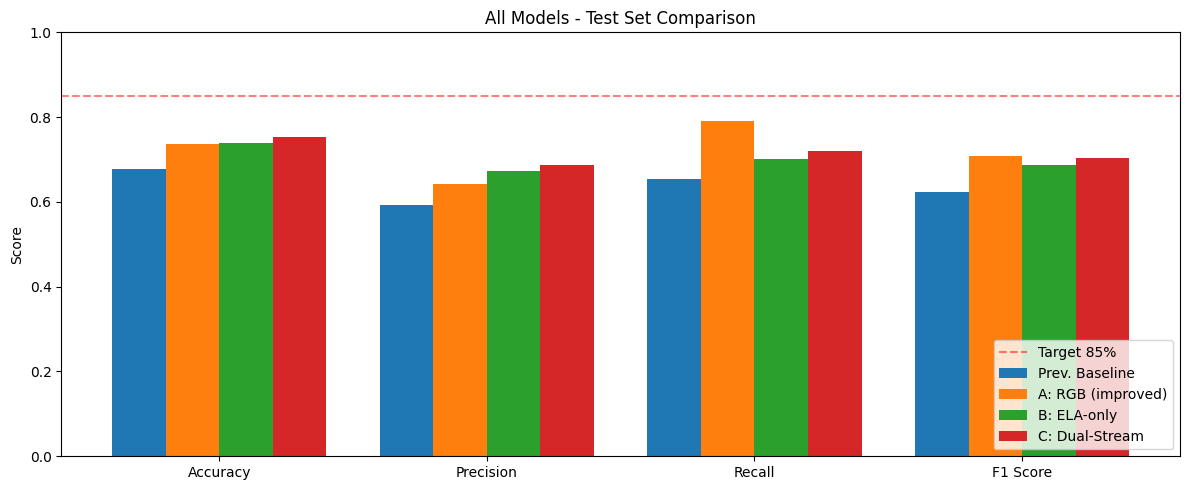

In [11]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1 Score']
order = ['Prev. Baseline', 'A: RGB (improved)', 'B: ELA-only', 'C: Dual-Stream']
model_names = [n for n in order if n in results]

df = pd.DataFrame({m: [results[m][k] for k in metrics] for m in model_names}, index=metrics)
print('Test Set Comparison:')
print(df.round(4).to_string())

x = np.arange(len(metrics))
width = 0.2
fig, ax = plt.subplots(figsize=(12, 5))
for i, name in enumerate(model_names):
    vals = [results[name][m] for m in metrics]
    offset = (i - len(model_names)/2 + 0.5) * width
    ax.bar(x + offset, vals, width, label=name)

ax.set_ylabel('Score')
ax.set_title('All Models - Test Set Comparison')
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylim(0, 1)
ax.axhline(y=0.85, color='red', linestyle='--', alpha=0.5, label='Target 85%')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

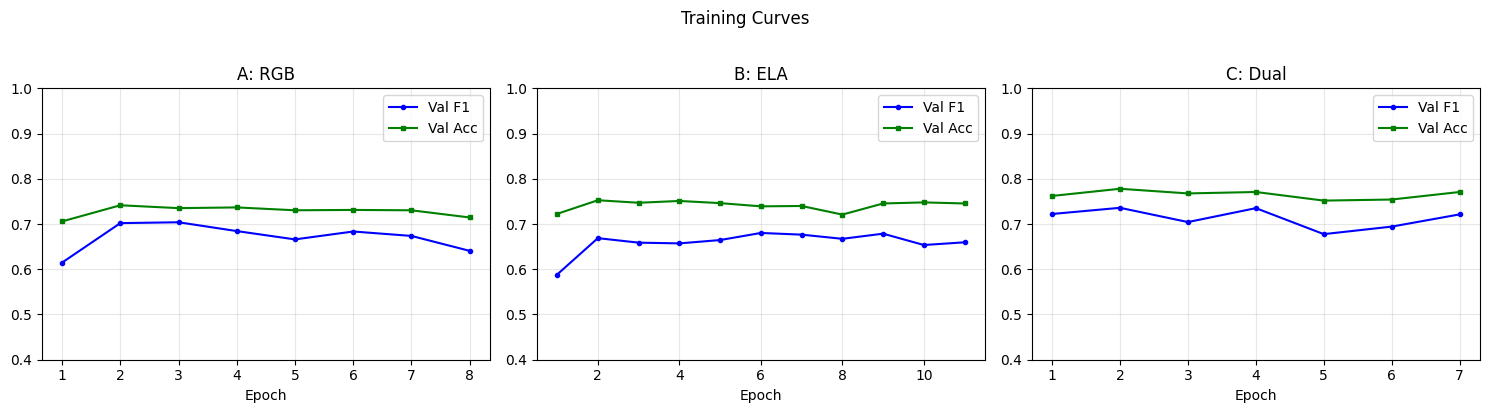

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, (name, hist) in zip(axes, [('A: RGB', hist_a), ('B: ELA', hist_b), ('C: Dual', hist_c)]):
    epochs = range(1, len(hist['val_f1']) + 1)
    ax.plot(epochs, hist['val_f1'], 'b-o', markersize=3, label='Val F1')
    ax.plot(epochs, hist['val_acc'], 'g-s', markersize=3, label='Val Acc')
    ax.set_title(name)
    ax.set_xlabel('Epoch')
    ax.set_ylim(0.4, 1.0)
    ax.legend()
    ax.grid(True, alpha=0.3)
plt.suptitle('Training Curves', y=1.02)
plt.tight_layout()
plt.show()